# Simulación de procesos de ruina del jugador

### Definición de librerías y funciones

In [1]:
from numpy import array, diag, zeros, eye, where, linspace, ones, prod
from numpy.linalg import pinv,svd
from matplotlib.pyplot import plot,spy,legend,title

### Definición de proceso genérico

In [2]:
def modelo_rdj(N,p=0.5):
    A = zeros((N+1,N+1))
    A[0,0] = A[N,N] = 1
    for j in range(N-1):
        A[j+1,j] = 1-p
        A[j+1,j+2] = p
    return A

In [3]:
# Fortuna máxima esperada por el jugador
N = 10
# Fortuna inicial del jugador
i = 2
# Probabilidad de ganar
p = 0.5
# Horizonte de tiempo de la simulación
T = 200

In [4]:
A = modelo_rdj(N,p)

In [5]:
A

array([[1. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ],
       [0.5, 0. , 0.5, 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ],
       [0. , 0.5, 0. , 0.5, 0. , 0. , 0. , 0. , 0. , 0. , 0. ],
       [0. , 0. , 0.5, 0. , 0.5, 0. , 0. , 0. , 0. , 0. , 0. ],
       [0. , 0. , 0. , 0.5, 0. , 0.5, 0. , 0. , 0. , 0. , 0. ],
       [0. , 0. , 0. , 0. , 0.5, 0. , 0.5, 0. , 0. , 0. , 0. ],
       [0. , 0. , 0. , 0. , 0. , 0.5, 0. , 0.5, 0. , 0. , 0. ],
       [0. , 0. , 0. , 0. , 0. , 0. , 0.5, 0. , 0.5, 0. , 0. ],
       [0. , 0. , 0. , 0. , 0. , 0. , 0. , 0.5, 0. , 0.5, 0. ],
       [0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0.5, 0. , 0.5],
       [0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 1. ]])

In [6]:
q0 = zeros(N+1)
q0[i] = 1

In [7]:
q = zeros((T,N+1))
q[0,:] = q0
for k in range(T-1):
    q[k+1,:] = q[k,:]@A

Text(0.5, 1.0, 'Evolución de probabilidades $\\mathbf{p}(t)$')

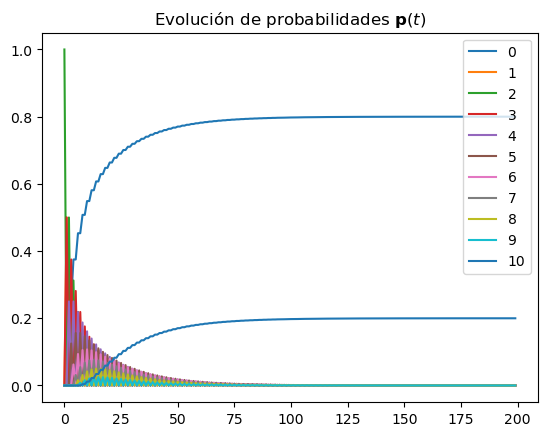

In [8]:
Legend = []
for j in range(N+1):
    Legend.append(str(j))
plot(q);legend(Legend);title('Evolución de probabilidades $\mathbf{p}(t)$')

Text(0.5, 1.0, 'Esperanza de Fortuna $\\mathbb{E}(f(t))$')

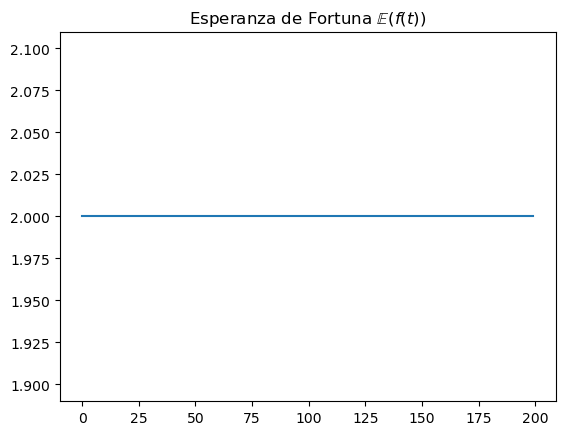

In [9]:
plot(q@linspace(0,N,N+1));title('Esperanza de Fortuna $\mathbb{E}(f(t))$')

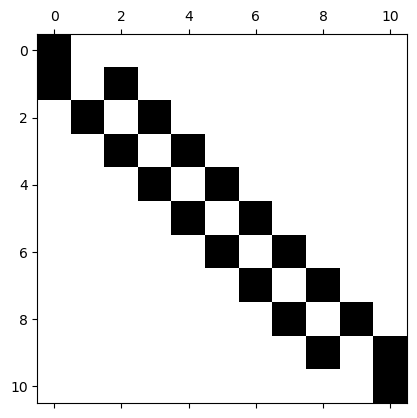

In [10]:
spy(A)

In [11]:
Ne = 100
Ar = pinv(q[:Ne,:])@q[1:(Ne+1),:]
Ar = Ar*(abs(Ar)>1e-11)
Ar

array([[ 0.97297297,  0.        ,  0.        ,  0.00965251,  0.01930502,
         0.02895753,  0.03861004,  0.04826255,  0.05791506,  0.02895753,
         0.10810811],
       [ 0.37837838, -0.        ,  0.5       ,  0.00772201,  0.01544402,
         0.02316602,  0.03088803,  0.03861004,  0.04633205,  0.02316602,
        -0.01351351],
       [ 0.        ,  0.5       , -0.        ,  0.5       , -0.        ,
        -0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ],
       [ 0.12162162, -0.        ,  0.5       , -0.00772201,  0.48455598,
        -0.02316602, -0.03088803, -0.03861004, -0.04633205, -0.02316602,
         0.01351351],
       [ 0.02702703,  0.        , -0.        ,  0.49034749, -0.01930502,
         0.47104247, -0.03861004, -0.04826255, -0.05791506, -0.02895753,
        -0.10810811],
       [-0.06756757, -0.        , -0.        , -0.01158301,  0.47683398,
        -0.03474903,  0.45366795, -0.05791506, -0.06949807, -0.03474903,
        -0.229

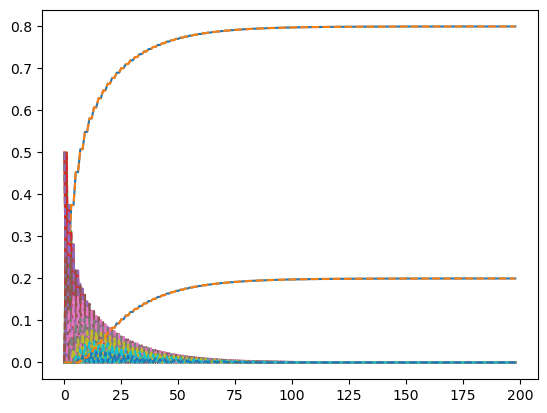

In [12]:
plot(q[1:,:]);plot(q[:-1,:]@Ar,'--');

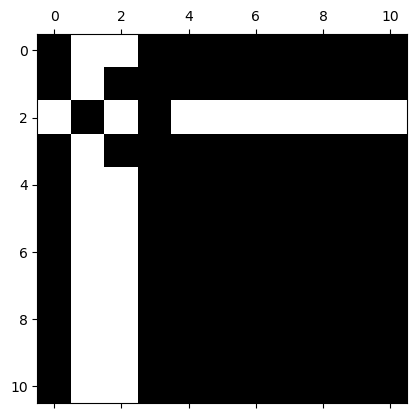

In [13]:
spy(Ar)

In [14]:
u,s,v = svd(eye(N+1,N+1)-A.T)

In [15]:
fs = where(s==0)[0]
pi = (v[fs,:]@q[-1,:])@v[fs,:]
pi = pi/sum(pi)
pi@A-pi

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

([<matplotlib.lines.Line2D at 0x238c407aee0>],
 <matplotlib.legend.Legend at 0x238c4040df0>)

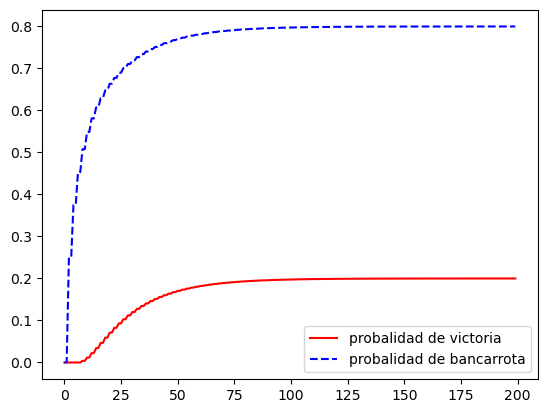

In [16]:
plot(q[:,-1],'r');plot(q[:,0],'b--'),legend(['probalidad de victoria','probalidad de bancarrota'])

In [17]:
pi

array([0.80001051, 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.19998949])

In [18]:
SM = abs(A>0).astype('int')

In [19]:
SM

array([[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]])

In [20]:
from TransitionMatrix import TransitionMatrix
Ar1 = TransitionMatrix(q.T,SM = SM,sample_size = 150,error = 1e-8,nz = 33).T

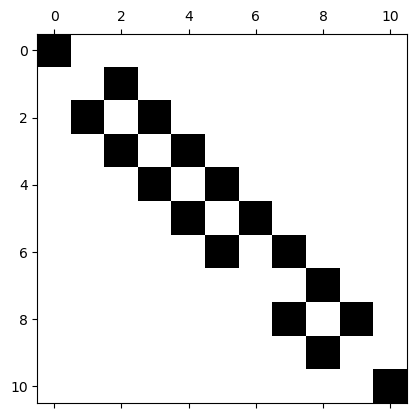

In [21]:
spy(Ar1)

In [22]:
Ar1

array([[1.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 1.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        ],
       [0.        , 0.5       , 0.        , 0.5       , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.19668349, 0.        , 0.80331651,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , 0.5       , 0.        ,
        0.5       , 0.        , 0.        , 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.00813032,
        0.        , 0.99186968, 0.        , 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.

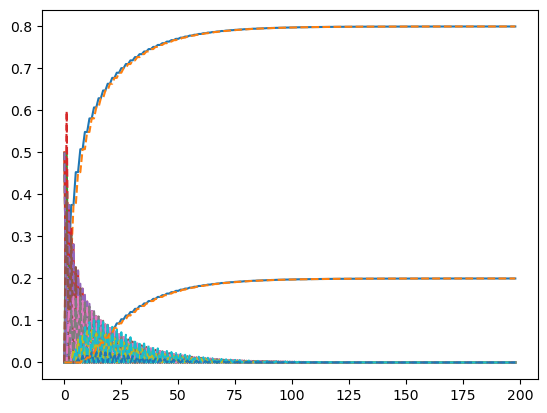

In [23]:
plot(q[1:,:]);plot(q[:-1,:]@Ar1,'--');

In [24]:
sum(Ar1.T)

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [25]:
Ar1[0,:]

array([1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [26]:
Ar1[1,:]

array([0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.])

In [27]:
q0

array([0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.])

In [28]:
q1 = q.copy()
for j in range(T-1):
    q1[j+1,:] = q1[j+1,:]@Ar1

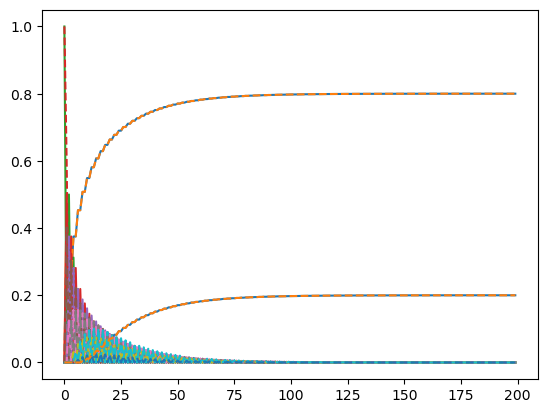

In [29]:
plot(q);plot(q1,'--');

In [30]:
Ar1

array([[1.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 1.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        ],
       [0.        , 0.5       , 0.        , 0.5       , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.19668349, 0.        , 0.80331651,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , 0.5       , 0.        ,
        0.5       , 0.        , 0.        , 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.00813032,
        0.        , 0.99186968, 0.        , 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.

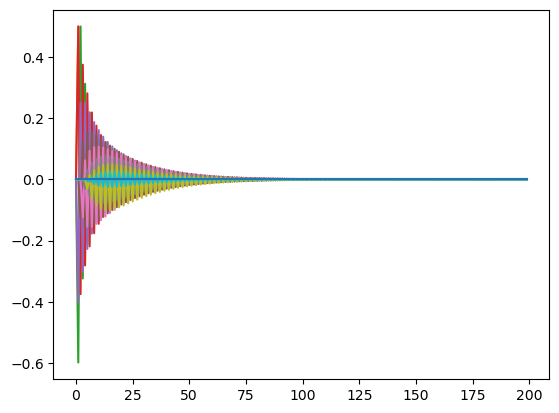

In [31]:
plot(q-q1);

In [32]:
MatrixList = []
MatrixList.append(diag([1,0,0,0,0,0,0,0,0,0,0]))
MatrixList.append(diag([1,1,1,1,1,1,1,1,1,0],-1).T)
MatrixList.append(diag([0,1,1,1,1,1,1,1,1,1],1).T)
MatrixList.append(diag([0,0,0,0,0,0,0,0,0,0,1]))
MatrixList

[array([[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]),
 array([[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]),
 array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       

In [33]:
MatrixList==MatrixList

True

In [34]:
A1 = array([[0.95,0.04,0,0],[0.05,0.85,0,0],[0,0.1,1,0],[0,0.01,0,1]])

In [35]:
A1

array([[0.95, 0.04, 0.  , 0.  ],
       [0.05, 0.85, 0.  , 0.  ],
       [0.  , 0.1 , 1.  , 0.  ],
       [0.  , 0.01, 0.  , 1.  ]])

In [36]:
proceso = zeros((4,200))
proceso[0,0] = 1
for j in range(199):
    proceso[:,j+1] = A1@proceso[:,j]

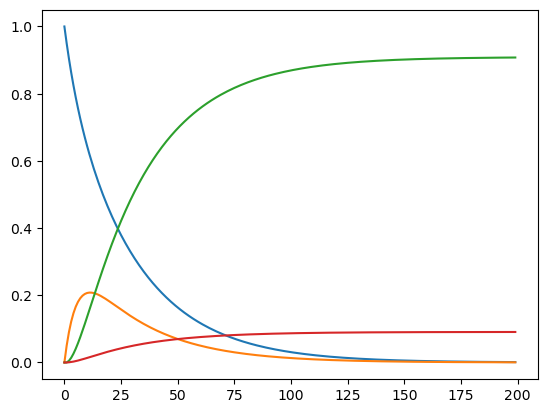

In [37]:
plot(proceso.T)

In [38]:
A1r = proceso[:,1:(51)]@pinv(proceso[:,:50])
A1r

array([[ 9.50000000e-01,  4.00000000e-02, -4.85722573e-17,
        -9.54097912e-18],
       [ 5.00000000e-02,  8.50000000e-01, -1.90819582e-17,
        -6.23416249e-17],
       [ 6.93889390e-18,  1.00000000e-01,  9.90099010e-01,
         9.90099010e-02],
       [ 1.43114687e-17,  1.00000000e-02,  9.90099010e-02,
         9.90099010e-03]])

In [39]:
proceso_r = 0*proceso
proceso_r[0,0] = 1
for j in range(199):
    proceso_r[:,j+1] = A1r@proceso_r[:,j]

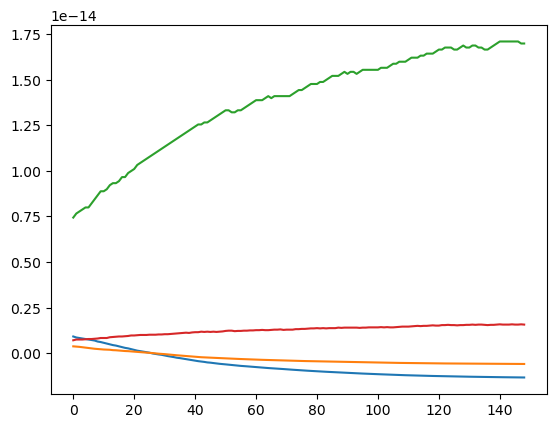

In [40]:
plot(proceso_r[:,51:].T-proceso[:,51:].T)

In [41]:
100*sum(sum((abs(A1-A1r)>1e-15).astype('int')))/prod(A1.shape)

25.0

In [42]:
SM1 = (abs(A1)>0).astype('int')

In [43]:
A1r2 = TransitionMatrix(proceso,sample_size=2,SM=SM1)

In [44]:
A1r2

array([[0.95, 0.04, 0.  , 0.  ],
       [0.05, 0.85, 0.  , 0.  ],
       [0.  , 0.1 , 1.  , 0.  ],
       [0.  , 0.01, 0.  , 1.  ]])

In [45]:
100*(1-sum(sum((abs(A1-A1r2)>1e-11).astype('int')))/prod(A1.shape))

100.0

In [46]:
A1

array([[0.95, 0.04, 0.  , 0.  ],
       [0.05, 0.85, 0.  , 0.  ],
       [0.  , 0.1 , 1.  , 0.  ],
       [0.  , 0.01, 0.  , 1.  ]])

In [47]:
Ar1 = TransitionMatrix(q.T,sample_size=1,SM=SM1,SB = MatrixList,SB_Index = [[0],[1,2],[3]])

In [48]:
Ar1.T

array([[1. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ],
       [0.5, 0. , 0.5, 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ],
       [0. , 0.5, 0. , 0.5, 0. , 0. , 0. , 0. , 0. , 0. , 0. ],
       [0. , 0. , 0.5, 0. , 0.5, 0. , 0. , 0. , 0. , 0. , 0. ],
       [0. , 0. , 0. , 0.5, 0. , 0.5, 0. , 0. , 0. , 0. , 0. ],
       [0. , 0. , 0. , 0. , 0.5, 0. , 0.5, 0. , 0. , 0. , 0. ],
       [0. , 0. , 0. , 0. , 0. , 0.5, 0. , 0.5, 0. , 0. , 0. ],
       [0. , 0. , 0. , 0. , 0. , 0. , 0.5, 0. , 0.5, 0. , 0. ],
       [0. , 0. , 0. , 0. , 0. , 0. , 0. , 0.5, 0. , 0.5, 0. ],
       [0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0.5, 0. , 0.5],
       [0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 1. ]])

In [49]:
100*(1-sum(sum((abs(A-Ar1.T)>1e-12).astype('int')))/prod(A.shape))

100.0

In [50]:
A0 = A.copy()
A0[-1,-2] = 1/3
A0[-1,-1] = 2/3

In [51]:
A0

array([[1.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        ],
       [0.5       , 0.        , 0.5       , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        ],
       [0.        , 0.5       , 0.        , 0.5       , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.5       , 0.        , 0.5       ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , 0.5       , 0.        ,
        0.5       , 0.        , 0.        , 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.5       ,
        0.        , 0.5       , 0.        , 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.

In [52]:
q0 = q.copy()
for j in range(199):
    q0[j+1,:] = q0[j,:]@A0

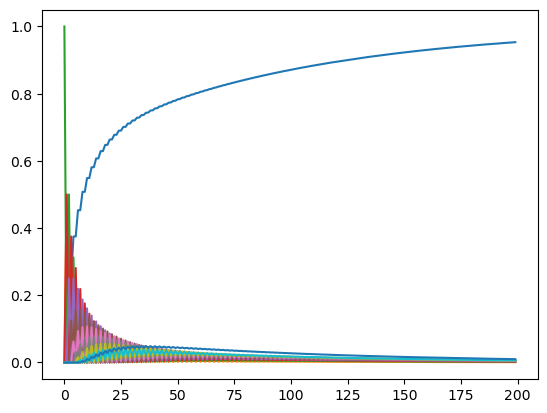

In [53]:
plot(q0)

In [54]:
Base = []
Base.append(diag([1,0,0,0,0,0,0,0,0,0,0]))
Base.append(diag([1,1,1,1,1,1,1,1,1,0],-1).T)
Base.append(diag([0,1,1,1,1,1,1,1,1,1],1).T)
Base.append(diag([0,0,0,0,0,0,0,0,0,1],-1).T)
Base.append(diag([0,0,0,0,0,0,0,0,0,0,1]))
Base

[array([[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]),
 array([[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]),
 array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       

In [55]:
A0r1 = TransitionMatrix(q0.T,sample_size=9,SM=SM1,SB = Base,SB_Index = [[0],[1,2],[3,4]])

In [56]:
A0r1.T

array([[1.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        ],
       [0.5       , 0.        , 0.5       , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        ],
       [0.        , 0.5       , 0.        , 0.5       , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.5       , 0.        , 0.5       ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , 0.5       , 0.        ,
        0.5       , 0.        , 0.        , 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.5       ,
        0.        , 0.5       , 0.        , 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.

In [57]:
100*(1-sum(sum((abs(A0-A0r1.T)>1e-10).astype('int')))/prod(A.shape))

100.0

In [58]:
from numpy.random import rand
P0 = rand(3,3)
P0 = P0@diag(1/sum(P0))
P0

array([[0.24470109, 0.3637958 , 0.33739242],
       [0.37193953, 0.50454803, 0.51514879],
       [0.38335938, 0.13165617, 0.14745879]])

In [59]:
p0 = zeros((3,200))
p0[0,0] = 1
for j in range(199):
    p0[:,j+1] = P0@p0[:,j]

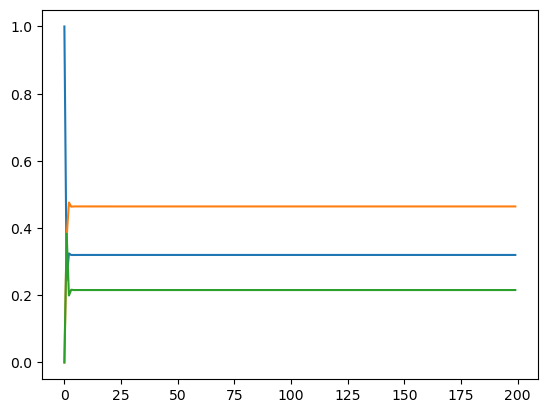

In [60]:
plot(p0.T)

In [61]:
def SRep(datos,ss):
    from numpy import kron, identity
    from scipy.optimize import nnls
    n0 = datos.shape[0]
    S0 = datos[:,:ss]
    S0 = kron(S0,identity(n0)).T
    S1 = S0.T@((datos[:,1:(1+ss)]).T).reshape(ss*n0)
    C = kron(identity(n0),ones((1,n0)))
    Mr = zeros((n0**2+n0,n0**2))
    Mr[:n0**2,:] = S0.T@S0
    Mr[n0**2:,:] = C
    rhs = zeros((n0**2+n0))
    rhs[:n0**2] = S1
    rhs[n0**2:] = 1
    c = zeros((n0**2,1))
    c[:,0] = nnls(Mr,rhs)[0]
    Pr = c.reshape(n0,n0).T
    Pr = Pr@diag(1/sum(Pr))
    return Pr

In [62]:
P0

array([[0.24470109, 0.3637958 , 0.33739242],
       [0.37193953, 0.50454803, 0.51514879],
       [0.38335938, 0.13165617, 0.14745879]])

In [63]:
P0r = SRep(p0,ss = 10)
P0r

array([[0.24470109, 0.3637958 , 0.33739242],
       [0.37193953, 0.50454803, 0.51514879],
       [0.38335938, 0.13165617, 0.14745879]])

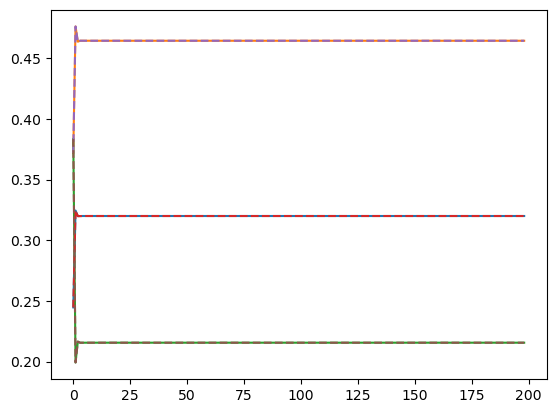

In [64]:
plot(p0[:,1:].T);plot((P0r@p0[:,:-1]).T,'--')

In [65]:
A1r3 = SRep(q0.T,ss = 9)

In [66]:
100*(1-sum(sum((abs(A1r3.T-A)>1e-10).astype('int')))/prod(A.shape))

98.34710743801654